   Elephant Herding Optimization (EHO)
   دالة Sphere  |  dim=10  |  الحد [-5.12, 5.12]
Iter    1/200  |  Best Fitness = 0.070786
Iter   10/200  |  Best Fitness = 0.003870
Iter   20/200  |  Best Fitness = 0.002584
Iter   30/200  |  Best Fitness = 0.000328
Iter   40/200  |  Best Fitness = 0.000178
Iter   50/200  |  Best Fitness = 0.000125
Iter   60/200  |  Best Fitness = 0.000096
Iter   70/200  |  Best Fitness = 0.000083
Iter   80/200  |  Best Fitness = 0.000037
Iter   90/200  |  Best Fitness = 0.000037
Iter  100/200  |  Best Fitness = 0.000037
Iter  110/200  |  Best Fitness = 0.000037
Iter  120/200  |  Best Fitness = 0.000037
Iter  130/200  |  Best Fitness = 0.000037
Iter  140/200  |  Best Fitness = 0.000037
Iter  150/200  |  Best Fitness = 0.000037
Iter  160/200  |  Best Fitness = 0.000037
Iter  170/200  |  Best Fitness = 0.000037
Iter  180/200  |  Best Fitness = 0.000037
Iter  190/200  |  Best Fitness = 0.000037
Iter  200/200  |  Best Fitness = 0.000037

  أفضل قيمة للدالة : 0.000036

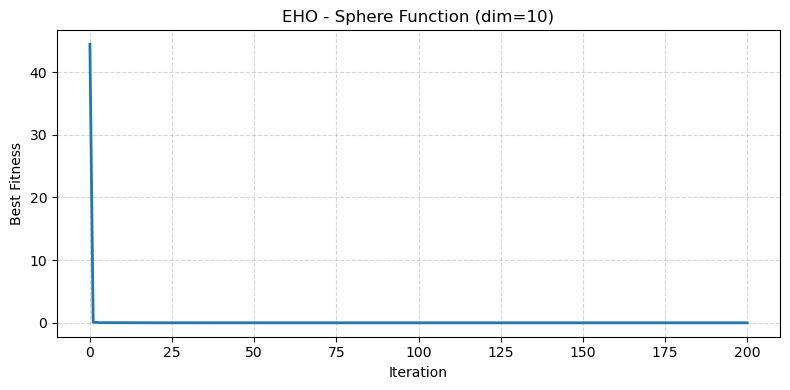

Convergence curve saved.


In [2]:
"""
Elephant Herding Optimization (EHO)
مستوحاة من: Wang et al. (2015) "Elephant Herding Optimization"
"""

import numpy as np
import matplotlib.pyplot as plt


class EHO:
    """
    خوارزمية تحسين قطيع الفيلة (EHO)

    المعاملات:
        n_clans     : عدد القبائل (clans)
        clan_size   : حجم كل قبيلة
        alpha       : معامل التحديث داخل القبيلة  [0, 1]
        beta        : معامل الأفضل العالمي          [0, 1]
        p_sep       : احتمالية فصل الفيل الأسوأ
        max_iter    : أقصى عدد من التكرارات
        lb, ub      : حدود مساحة البحث
        dim         : أبعاد المسألة
        minimize    : True للتقليل، False للتكبير
    """

    def __init__(
        self,
        fitness_func,
        dim: int,
        lb,
        ub,
        n_clans: int = 5,
        clan_size: int = 10,
        alpha: float = 0.5,
        beta: float = 0.1,
        p_sep: float = 1.0,
        max_iter: int = 100,
        minimize: bool = True,
    ):
        self.fitness_func = fitness_func
        self.dim = dim
        self.lb = np.array(lb) if hasattr(lb, "__len__") else np.full(dim, lb)
        self.ub = np.array(ub) if hasattr(ub, "__len__") else np.full(dim, ub)
        self.n_clans = n_clans
        self.clan_size = clan_size
        self.alpha = alpha
        self.beta = beta
        self.p_sep = p_sep
        self.max_iter = max_iter
        self.minimize = minimize

        self.n_elephants = n_clans * clan_size
        self.best_position = None
        self.best_fitness = np.inf if minimize else -np.inf
        self.history = []

    # ------------------------------------------------------------------ #
    #  تهيئة السكان                                                        #
    # ------------------------------------------------------------------ #
    def _initialize(self):
        """توليد السكان الأولي عشوائيًا."""
        pop = np.random.uniform(
            self.lb, self.ub, (self.n_elephants, self.dim)
        )
        return pop

    def _evaluate(self, pop):
        return np.array([self.fitness_func(ind) for ind in pop])

    def _is_better(self, a, b):
        return a < b if self.minimize else a > b

    # ------------------------------------------------------------------ #
    #  مرحلة تحديث القبيلة (Clan Updating Operator)                       #
    # ------------------------------------------------------------------ #
    def _clan_update(self, pop, fitness):
        new_pop = pop.copy()
        # تقسيم السكان إلى قبائل
        clans_idx = np.array_split(np.arange(self.n_elephants), self.n_clans)

        for clan_idx in clans_idx:
            clan_fitness = fitness[clan_idx]
            # أفضل فيل في القبيلة
            if self.minimize:
                best_local = clan_idx[np.argmin(clan_fitness)]
            else:
                best_local = clan_idx[np.argmax(clan_fitness)]

            x_best_clan = pop[best_local]

            for i in clan_idx:
                # معادلة التحديث الأساسية
                r = np.random.uniform(0, 1, self.dim)
                new_pop[i] = pop[i] + self.alpha * r * (x_best_clan - pop[i])

            # تحديث أفضل فيل في القبيلة بمركز القبيلة
            x_center = np.mean(pop[clan_idx], axis=0)
            new_pop[best_local] = self.beta * x_center

        # تطبيق الحدود (boundary clamping)
        new_pop = np.clip(new_pop, self.lb, self.ub)
        return new_pop

    # ------------------------------------------------------------------ #
    #  مرحلة الفصل (Separating Operator)                                   #
    # ------------------------------------------------------------------ #
    def _separating(self, pop, fitness):
        new_pop = pop.copy()
        clans_idx = np.array_split(np.arange(self.n_elephants), self.n_clans)

        for clan_idx in clans_idx:
            if np.random.rand() < self.p_sep:
                clan_fitness = fitness[clan_idx]
                # أسوأ فيل في القبيلة
                if self.minimize:
                    worst_local = clan_idx[np.argmax(clan_fitness)]
                else:
                    worst_local = clan_idx[np.argmin(clan_fitness)]

                # استبداله بموقع عشوائي جديد
                new_pop[worst_local] = np.random.uniform(self.lb, self.ub, self.dim)

        return new_pop

    # ------------------------------------------------------------------ #
    #  حلقة التحسين الرئيسية                                              #
    # ------------------------------------------------------------------ #
    def optimize(self, verbose: bool = True):
        pop = self._initialize()
        fitness = self._evaluate(pop)

        # تسجيل الأفضل الأولي
        if self.minimize:
            best_idx = np.argmin(fitness)
        else:
            best_idx = np.argmax(fitness)

        self.best_position = pop[best_idx].copy()
        self.best_fitness = fitness[best_idx]
        self.history = [self.best_fitness]

        for t in range(1, self.max_iter + 1):
            # --- 1. تحديث القبيلة ---
            pop = self._clan_update(pop, fitness)
            fitness = self._evaluate(pop)

            # --- 2. الفصل ---
            pop = self._separating(pop, fitness)
            fitness = self._evaluate(pop)

            # --- تحديث الأفضل العالمي ---
            if self.minimize:
                best_idx = np.argmin(fitness)
            else:
                best_idx = np.argmax(fitness)

            if self._is_better(fitness[best_idx], self.best_fitness):
                self.best_position = pop[best_idx].copy()
                self.best_fitness = fitness[best_idx]

            self.history.append(self.best_fitness)

            if verbose and (t % 10 == 0 or t == 1):
                print(f"Iter {t:4d}/{self.max_iter}  |  Best Fitness = {self.best_fitness:.6f}")

        return self.best_position, self.best_fitness

    # ------------------------------------------------------------------ #
    #  رسم منحنى التقارب                                                   #
    # ------------------------------------------------------------------ #
    def plot_convergence(self, title: str = "EHO - Convergence Curve"):
        plt.figure(figsize=(8, 4))
        plt.plot(self.history, color="#1f77b4", linewidth=2)
        plt.xlabel("Iteration")
        plt.ylabel("Best Fitness")
        plt.title(title)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.savefig("eho_convergence.png", dpi=150)
        plt.show()
        print("Convergence curve saved.")


# ===================================================================== #
#  مثال تطبيقي: دالة Sphere (أبسط دالة قياسية)                          #
# ===================================================================== #
def sphere(x):
    return np.sum(x ** 2)


# مثال ثانٍ: دالة Rosenbrock (أصعب)
def rosenbrock(x):
    return sum(
        100 * (x[i + 1] - x[i] ** 2) ** 2 + (1 - x[i]) ** 2
        for i in range(len(x) - 1)
    )


if __name__ == "__main__":
    DIM = 10       # عدد المتغيرات
    LB  = -5.12   # الحد الأدنى
    UB  =  5.12   # الحد الأعلى

    print("=" * 55)
    print("   Elephant Herding Optimization (EHO)")
    print("   دالة Sphere  |  dim=10  |  الحد [-5.12, 5.12]")
    print("=" * 55)

    eho = EHO(
        fitness_func=sphere,
        dim=DIM,
        lb=LB,
        ub=UB,
        n_clans=5,
        clan_size=10,
        alpha=0.5,
        beta=0.1,
        p_sep=1.0,
        max_iter=200,
        minimize=True,
    )

    best_pos, best_fit = eho.optimize(verbose=True)

    print("\n" + "=" * 55)
    print(f"  أفضل قيمة للدالة : {best_fit:.8f}")
    print(f"  أفضل موقع        : {np.round(best_pos, 4)}")
    print("=" * 55)

    eho.plot_convergence("EHO - Sphere Function (dim=10)")
